# Arabic Sentiment Analysis
Classifying Arabic tweets as Positive or Negative using an LSTM deep learning model.  
**Dataset:** Arabic Twitter Corpus (Positive & Negative tweets)  
**Model:** LSTM with Embedding and Dropout  
**Val Accuracy:** 77.5%

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

## Loading and Exploring the data

In [3]:
train_pos = pd.read_csv('train_Arabic_tweets_positive_20190413.tsv',sep='\t', header=None, names=['label', 'text'])
train_neg = pd.read_csv('train_Arabic_tweets_negative_20190413.tsv',sep='\t', header=None, names=['label', 'text'])

test_pos = pd.read_csv('test_Arabic_tweets_positive_20190413.tsv',sep='\t', header=None, names=['label', 'text'])
test_neg = pd.read_csv('test_Arabic_tweets_negative_20190413.tsv',sep='\t', header=None, names=['label', 'text'])

In [4]:
print(train_pos.head())

  label                                               text
0   pos  نحن الذين يتحول كل ما نود أن نقوله إلى دعاء لل...
1   pos  وفي النهاية لن يبقىٰ معك آحدإلا من رأىٰ الجمال...
2   pos                                    من الخير نفسه 💛
3   pos  #زلزل_الملعب_نصرنا_بيلعب كن عالي الهمه ولا ترض...
4   pos  الشيء الوحيد الذي وصلوا فيه للعالمية هو : المس...


In [5]:
print(train_neg.head())

  label                                               text
0   neg  اعترف ان بتس كانو شوي شوي يجيبو راسي لكن اليوم...
1   neg  توقعت اذا جات داريا بشوفهم كاملين بس لي للحين ...
2   neg  #الاهلي_الهلال اكتب توقعك لنتيجة لقاء الهلال و...
3   neg  نعمة المضادات الحيوية . تضع قطرة💧مضاد بنسلين ع...
4   neg                             الدودو جايه تكمل علي 💔


## Cleaning function

In [6]:
def cleaning(text):
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#', '', text)
    text = re.sub(r'[\u0617-\u061A\u064B-\u0652]', '', text)
    text = re.sub(r'[^\u0600-\u06FF\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text


In [7]:
train_pos['text'] = train_pos['text'].apply(cleaning)
train_neg['text'] = train_neg['text'].apply(cleaning)
test_pos['text'] = test_pos['text'].apply(cleaning)
test_neg['text'] = test_neg['text'].apply(cleaning)


In [8]:
print(train_pos.head())

  label                                               text
0   pos  نحن الذين يتحول كل ما نود أن نقوله إلى دعاء لل...
1   pos  وفي النهاية لن يبقىٰ معك آحدإلا من رأىٰ الجمال...
2   pos                                      من الخير نفسه
3   pos  زلزلالملعبنصرنابيلعب كن عالي الهمه ولا ترضى بغ...
4   pos  الشيء الوحيد الذي وصلوا فيه للعالمية هو المسيا...


In [9]:
print(train_neg.head())

  label                                               text
0   neg  اعترف ان بتس كانو شوي شوي يجيبو راسي لكن اليوم...
1   neg  توقعت اذا جات داريا بشوفهم كاملين بس لي للحين ...
2   neg  الاهليالهلال اكتب توقعك لنتيجة لقاء الهلال وال...
3   neg  نعمة المضادات الحيوية تضع قطرةمضاد بنسلين على ...
4   neg                               الدودو جايه تكمل علي


## Combining and Encoding 

In [10]:
train_df = pd.concat([train_pos, train_neg], ignore_index=True)
test_df = pd.concat([test_pos, test_neg], ignore_index=True)

train_df['label'] = train_df['label'].map({'pos': 1, 'neg': 0})
test_df['label'] = test_df['label'].map({'pos': 1, 'neg': 0})

train_df = train_df.sample(frac=1, random_state=42).reset_index(drop=True)
test_df = test_df.sample(frac=1, random_state=42).reset_index(drop=True)

In [11]:
print(train_df.head())

   label                                               text
0      1                مقال يدور حول الحمى يوشك ان يقع فيه
1      1                                       تيشرت القائد
2      0  وكل السعوديه بدو حتى الحاضره منهم من اصل بدوي ...
3      0                          المونافري طلع برهوش سدينا
4      0                                 منو خر بيتهم مثلنا


In [12]:
print(test_df.head())

   label                                               text
0      1  مسابقة والجائزة من أول من فتق لسانه بالعربية ؟...
1      0  ما لأبن أدم والفخر اوله نطفه وأخره جيفه ولا ير...
2      1  لاتحزن ودع القلقيستجيب لك الكريم هو يأخرها لوق...
3      0  بيي الله يستر طلعتي من الدوام سيارتي وايد نازل...
4      0  تلاتين سنة بترقص الليلة رقصتنا أنا ببكي دي حلا...


## EDA

Training set:
label
1    22761
0    22514
Name: count, dtype: int64

Testing set:
label
0    5768
1    5752
Name: count, dtype: int64


C:\Users\Ahmad\AppData\Local\Temp\ipykernel_13768\1524009348.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='label', data=train_df, palette='Set2')
C:\Users\Ahmad\AppData\Local\Temp\ipykernel_13768\1524009348.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='label', data=test_df, palette='Set2')


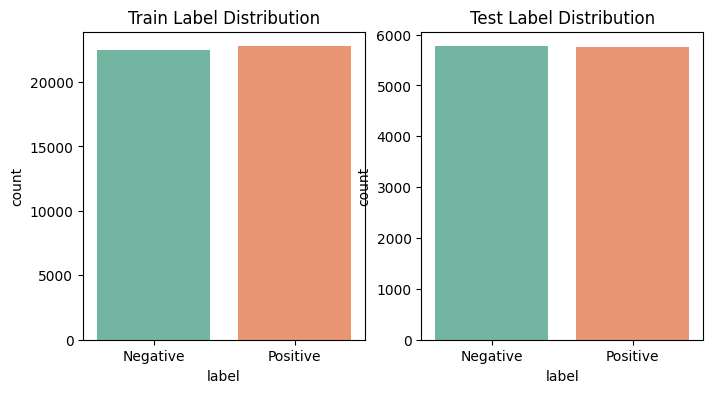

In [13]:
print("Training set:")
print(train_df['label'].value_counts())
print()
print("Testing set:")
print(test_df['label'].value_counts())

plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
sns.countplot(x='label', data=train_df, palette='Set2')
plt.title('Train Label Distribution')
plt.xticks([0,1], ['Negative', 'Positive'])

plt.subplot(1,2,2)
sns.countplot(x='label', data=test_df, palette='Set2')
plt.title('Test Label Distribution')
plt.xticks([0,1], ['Negative', 'Positive'])
plt.show()

## Tokenization & Padding

In [14]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [15]:
tokenizer = Tokenizer(num_words=10000, oov_token='<OOV>')
tokenizer.fit_on_texts(train_df['text'])

In [16]:
X_train = tokenizer.texts_to_sequences(train_df['text'])
X_test = tokenizer.texts_to_sequences(test_df['text'])

In [17]:
X_train = pad_sequences(X_train, maxlen=50, padding='pre', truncating='post')
X_test = pad_sequences(X_test, maxlen=50, padding='pre', truncating='post')

In [18]:
y_train = train_df['label'].values
y_test = test_df['label'].values

In [19]:
print(X_train.shape)
print(X_test.shape)

(45275, 50)
(11520, 50)


## LSTM model building

In [20]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout

model = Sequential([
    Embedding(input_dim=10000, output_dim=64, input_length=50),
    LSTM(64, return_sequences=False),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
model.build(input_shape=(None, 50))
model.summary()

c:\Users\Ahmad\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 50, 64)         │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 673,089 (2.57 MB)

 Trainable params: 673,089 (2.57 MB)

 Non-trainable params: 0 (0.00 B)

In [21]:
history = model.fit(
    X_train, y_train,
    epochs=5,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/5
1415/1415 ━━━━━━━━━━━━━━━━━━━━ 19s 13ms/step - accuracy: 0.7219 - loss: 0.5161 - val_accuracy: 0.7602 - val_loss: 0.4583
Epoch 2/5
1415/1415 ━━━━━━━━━━━━━━━━━━━━ 18s 12ms/step - accuracy: 0.8074 - loss: 0.3917 - val_accuracy: 0.7716 - val_loss: 0.4544
Epoch 3/5
1415/1415 ━━━━━━━━━━━━━━━━━━━━ 17s 12ms/step - accuracy: 0.8399 - loss: 0.3285 - val_accuracy: 0.7674 - val_loss: 0.4791
Epoch 4/5
1415/1415 ━━━━━━━━━━━━━━━━━━━━ 17s 12ms/step - accuracy: 0.8619 - loss: 0.2838 - val_accuracy: 0.7738 - val_loss: 0.5010
Epoch 5/5
1415/1415 ━━━━━━━━━━━━━━━━━━━━ 17s 12ms/step - accuracy: 0.8798 - loss: 0.2454 - val_accuracy: 0.7737 - val_loss: 0.6262


In [22]:
from tensorflow.keras import backend as K
K.clear_session()

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

model = Sequential([
    Embedding(input_dim=10000, output_dim=64, input_length=50),
    LSTM(64, return_sequences=False),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
model.build(input_shape=(None, 50))

early_stop = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[early_stop]
)


Epoch 1/20
1415/1415 ━━━━━━━━━━━━━━━━━━━━ 19s 12ms/step - accuracy: 0.7268 - loss: 0.5074 - val_accuracy: 0.7602 - val_loss: 0.4611
Epoch 2/20
1415/1415 ━━━━━━━━━━━━━━━━━━━━ 17s 12ms/step - accuracy: 0.8096 - loss: 0.3853 - val_accuracy: 0.7727 - val_loss: 0.4512
Epoch 3/20
1415/1415 ━━━━━━━━━━━━━━━━━━━━ 18s 12ms/step - accuracy: 0.8417 - loss: 0.3250 - val_accuracy: 0.7704 - val_loss: 0.4709
Epoch 4/20
1415/1415 ━━━━━━━━━━━━━━━━━━━━ 17s 12ms/step - accuracy: 0.8638 - loss: 0.2782 - val_accuracy: 0.7743 - val_loss: 0.5345


In [23]:
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {accuracy:.2f}")
print(f"Test Loss: {loss:.2f}")

360/360 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7727 - loss: 0.4512
Test Accuracy: 0.77
Test Loss: 0.45


## Training History

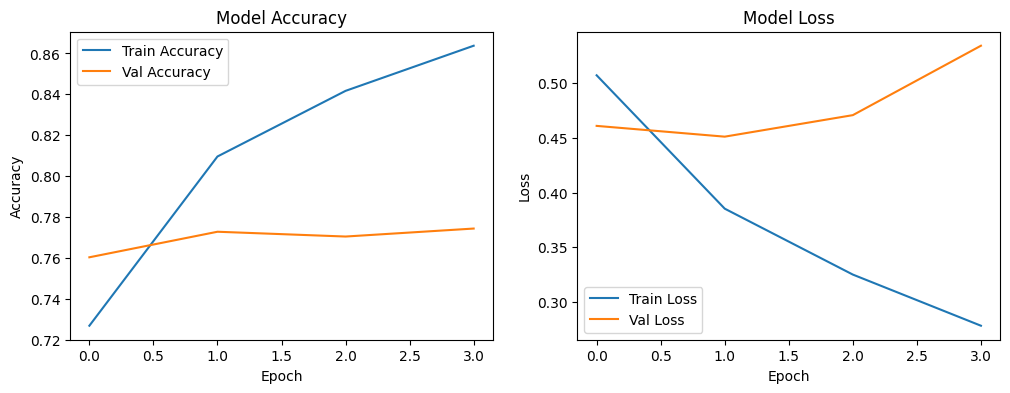

In [24]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

## Confusion Matric and Classification Report

360/360 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step
              precision    recall  f1-score   support

    Negative       0.74      0.83      0.79      5768
    Positive       0.81      0.71      0.76      5752

    accuracy                           0.77     11520
   macro avg       0.78      0.77      0.77     11520
weighted avg       0.78      0.77      0.77     11520



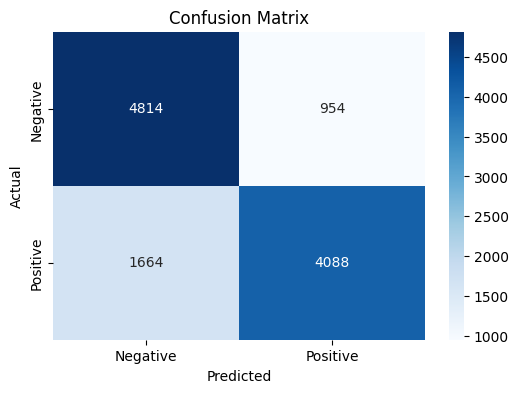

In [25]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = (model.predict(X_test) >= 0.5).astype(int)

print(classification_report(y_test, y_pred, target_names=['Negative', 'Positive']))

plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred),
            annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

### Testing and Predection function

In [26]:
def predict_sentiment(text):
    cleaned = cleaning(text)
    sequence = tokenizer.texts_to_sequences([cleaned])
    padded = pad_sequences(sequence, maxlen=50, padding='pre')
    prediction = model.predict(padded, verbose=0)[0][0]
    sentiment = "Positive" if prediction >= 0.5 else "Negative"
    print(f"Tweet: {text}")
    print(f"Sentiment: {sentiment}")
    print(f"Confidence: {prediction:.2f}")

In [27]:
predict_sentiment("الشحن كان وحش جدا بس خدمه العملا جميله وفعلا تعاملهم وطريقه كلامهم تغفر اي حاجة")

Tweet: الشحن كان وحش جدا بس خدمه العملا جميله وفعلا تعاملهم وطريقه كلامهم تغفر اي حاجة
Sentiment: Positive
Confidence: 0.69


In [28]:
predict_sentiment('وينهم الي يرقصوا مع زخات المطر 💃 خلونا نشوفكم لااه 😆 #خلفانيات فيروز كانت تحتسي كوب القه.. لا لا خلنا نغير تح…')

Tweet: وينهم الي يرقصوا مع زخات المطر 💃 خلونا نشوفكم لااه 😆 #خلفانيات فيروز كانت تحتسي كوب القه.. لا لا خلنا نغير تح…
Sentiment: Positive
Confidence: 0.89


In [29]:
predict_sentiment('الحمد لله .. كانت مباراه صعبه ولكن بتوفيق الله ثم دعمكم تجاوزنا المباراه 💙')

Tweet: الحمد لله .. كانت مباراه صعبه ولكن بتوفيق الله ثم دعمكم تجاوزنا المباراه 💙
Sentiment: Positive
Confidence: 1.00


In [30]:
predict_sentiment("المنتج تحفة جداً 😍❤️ وبيشتغل أحسن من اللي توقعته http://product.com")

Tweet: المنتج تحفة جداً 😍❤️ وبيشتغل أحسن من اللي توقعته http://product.com
Sentiment: Positive
Confidence: 0.91


In [31]:
predict_sentiment("لا والله التجربة دي أسوأ حاجة مريت بيها خالص 😡😡 مش هينفع")

Tweet: لا والله التجربة دي أسوأ حاجة مريت بيها خالص 😡😡 مش هينفع
Sentiment: Negative
Confidence: 0.20


In [32]:
predict_sentiment("مش عارف ليه الناس بتشتري منهم أصلاً خدمة زفت وبضاعة أزفت 💔")

Tweet: مش عارف ليه الناس بتشتري منهم أصلاً خدمة زفت وبضاعة أزفت 💔
Sentiment: Negative
Confidence: 0.05
